In [1]:
# %% 데이터 로드
import glob, os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# seaborn 스타일을 먼저 적용 (이게 폰트를 덮어쓸 수 있어서 순서 중요!)
sns.set_style('whitegrid')

# 그 다음 한글 폰트 (Windows)
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 출력 옵션
pd.set_option('display.max_columns', 60)
pd.set_option('display.float_format', '{:,.2f}'.format)
 
from pathlib import Path
 
current = Path.cwd()
project_root = current if (current / 'data').exists() else current.parent
 
# ── 추정매출 로드 (기존 코드 재사용) ──
DATA_DIR = str(project_root / 'data' / 'extracted' / '서울시_상권분석서비스(추정매출+영역)') + '/'
pattern = DATA_DIR + '*추정매출*.csv'
sales_files = sorted(glob.glob(pattern))
print(f'추정매출 파일: {len(sales_files)}개')
 
sales = pd.concat(
    [pd.read_csv(f, encoding='cp949', low_memory=False) for f in sales_files],
    ignore_index=True
)
print(f'  → 통합: {sales.shape[0]:,}행 × {sales.shape[1]}컬럼')
 
# ── 영역 로드 ──
area_path = glob.glob(DATA_DIR + '*영역*상권*.csv')[0]
area = pd.read_csv(area_path, encoding='cp949')
print(f'영역: {area.shape[0]:,}개 상권')
 
# ── 길단위인구(유동인구) 로드 ──
floating_path = project_root / 'data' / 'extracted' / '서울시 상권분석서비스(길단위인구-상권)' / '서울시 상권분석서비스(길단위인구-상권).csv'
floating = pd.read_csv(floating_path, encoding='cp949')
print(f'유동인구: {floating.shape[0]:,}행 × {floating.shape[1]}컬럼')
 
# ── 직장인구 로드 ──
work_path = project_root / 'data' / '06_직장인구' / '서울시 상권분석서비스(직장인구-상권).csv'
df_직장 = pd.read_csv(work_path, encoding='cp949')
print(f'직장인구: {df_직장.shape[0]:,}행 × {df_직장.shape[1]}컬럼')
 
# ── 상주인구 로드 ──
resident_path = project_root / 'data' / '07_상주인구' / '서울시 상권분석서비스(상주인구-상권).csv'
df_상주 = pd.read_csv(resident_path, encoding='cp949')
print(f'상주인구: {df_상주.shape[0]:,}행 × {df_상주.shape[1]}컬럼')
 
print('\n✅ 전체 데이터 로드 완료')

추정매출 파일: 6개
  → 통합: 519,931행 × 55컬럼
영역: 1,650개 상권
유동인구: 46,184행 × 27컬럼
직장인구: 45,840행 × 26컬럼
상주인구: 40,812행 × 29컬럼

✅ 전체 데이터 로드 완료


In [2]:
# ── 시간대 컬럼 정의 ──
시간_매출 = ['시간대_00~06_매출_금액','시간대_06~11_매출_금액','시간대_11~14_매출_금액',
           '시간대_14~17_매출_금액','시간대_17~21_매출_금액','시간대_21~24_매출_금액']
시간라벨 = ['00-06','06-11','11-14','14-17','17-21','21-24']

In [3]:
# ── 상권 단위로 시간대별 매출 합산 (업종 합침) ──
sales_time = sales.groupby(
    ['기준_년분기_코드', '상권_코드', '상권_구분_코드_명']
)[시간_매출 + ['당월_매출_금액']].sum().reset_index()

In [4]:
# ── 점심비중 계산 ──
sales_time['점심비중'] = sales_time['시간대_11~14_매출_금액'] / sales_time['당월_매출_금액'] * 100

In [5]:
# ── 직장인구와 merge ──
merged_work = sales_time.merge(
    df_직장[['기준_년분기_코드', '상권_코드', '총_직장_인구_수']],
    on=['기준_년분기_코드', '상권_코드'],
    how='inner'
)

In [6]:
# ── 영역 면적 merge (밀도 계산용) ──
merged_work = merged_work.merge(
    area[['상권_코드', '영역_면적']],
    on='상권_코드',
    how='left'
)
merged_work['직장인구밀도'] = merged_work['총_직장_인구_수'] / merged_work['영역_면적'].replace(0, np.nan)
 
print(f'병합 결과: {merged_work.shape[0]:,}행')
print(f'직장인구 범위: {merged_work["총_직장_인구_수"].min():,.0f} ~ {merged_work["총_직장_인구_수"].max():,.0f}명')

병합 결과: 37,461행
직장인구 범위: 1 ~ 214,604명


In [7]:
# %% 상권구분별 상관계수
상권 = ['골목상권', '발달상권', '관광특구', '전통시장']
 
print('📊 상권구분별 직장인구 vs 점심비중')
print('-' * 65)
print(f'{"상권유형":<10} {"평균직장인구":>10} {"평균점심비중":>10} {"상관(인구)":>10} {"상관(밀도)":>10}')
print('-' * 65)
for 구분 in 상권:
    sub = merged_work[merged_work['상권_구분_코드_명'] == 구분]
    corr_인구 = sub[['총_직장_인구_수', '점심비중']].corr().iloc[0, 1]
    corr_밀도 = sub[['직장인구밀도', '점심비중']].dropna().corr().iloc[0, 1]
    print(f'{구분:<10} {sub["총_직장_인구_수"].mean():>9,.0f}명 {sub["점심비중"].mean():>9.1f}%'
          f' {corr_인구:>9.3f} {corr_밀도:>9.3f}')

📊 상권구분별 직장인구 vs 점심비중
-----------------------------------------------------------------
상권유형           평균직장인구     평균점심비중     상관(인구)     상관(밀도)
-----------------------------------------------------------------
골목상권             792명      24.3%     0.079     0.140
발달상권          11,517명      27.1%     0.228     0.293
관광특구          87,833명      25.1%     0.552     0.317
전통시장             674명      24.6%     0.132     0.169


In [12]:
# %% 직장인구 5분위별 점심비중
# 실제 경계값으로 라벨 생성
merged_work['직장인구_구간'], bins = pd.qcut(
    merged_work['총_직장_인구_수'], q=5, retbins=True
)

# 경계값 기반 라벨 (마지막 구간은 '~이상'으로 처리)
라벨 = [f'{int(bins[i]):,}~{int(bins[i+1]):,}명' for i in range(4)]
라벨.append(f'{int(bins[4]):,}명 이상')

merged_work['직장인구_구간'] = pd.qcut(
    merged_work['총_직장_인구_수'], q=5, labels=라벨
)

print(f'📌 5분위 경계값: {라벨}')

구간별 = merged_work.groupby('직장인구_구간').agg(
    평균직장인구=('총_직장_인구_수', 'mean'),
    평균점심비중=('점심비중', 'mean'),
    평균점심매출=('시간대_11~14_매출_금액', 'mean'),
    n=('상권_코드', 'count')
).reset_index()

print('\n📊 직장인구 5분위별 점심시간(11-14시) 매출')
print('-' * 70)
print(f'{"구간":<16} {"평균직장인구":>10} {"점심비중":>8} {"점심매출(백만)":>12} {"n":>6}')
print('-' * 70)
for _, row in 구간별.iterrows():
    print(f'{row["직장인구_구간"]:<16} {row["평균직장인구"]:>9,.0f}명 {row["평균점심비중"]:>7.1f}%'
          f' {row["평균점심매출"]/1e6:>11,.0f} {row["n"]:>5,}')

📌 5분위 경계값: ['1~160명', '160~361명', '361~684명', '684~1,851명', '1,851명 이상']

📊 직장인구 5분위별 점심시간(11-14시) 매출
----------------------------------------------------------------------
구간                   평균직장인구     점심비중     점심매출(백만)      n
----------------------------------------------------------------------
1~160명                  83명    23.3%         528 7,517
160~361명               254명    23.2%       1,186 7,486
361~684명               501명    24.5%       1,481 7,489
684~1,851명           1,094명    25.1%       2,079 7,480
1,851명 이상           12,125명    27.7%      12,620 7,489


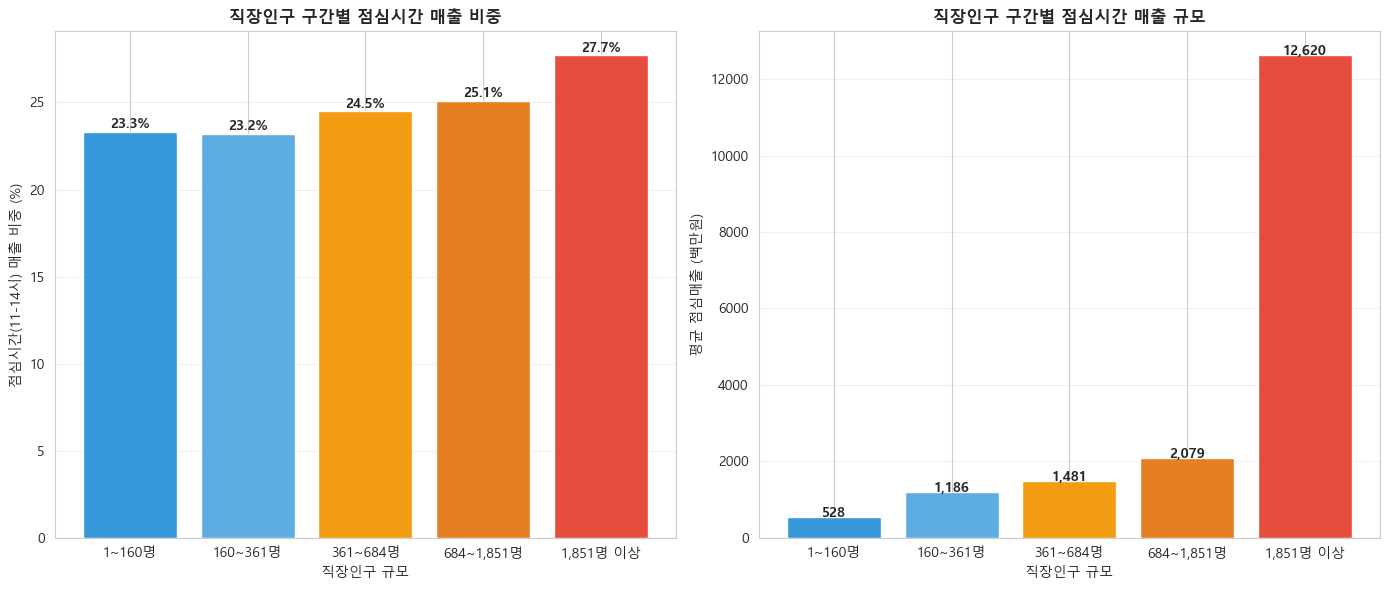

In [13]:
# %% 직장인구 구간별 점심비중 시각화
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
 
# (1) 구간별 점심비중
ax1 = axes[0]
colors = ['#3498DB', '#5DADE2', '#F39C12', '#E67E22', '#E74C3C']
bars = ax1.bar(구간별['직장인구_구간'], 구간별['평균점심비중'], color=colors, edgecolor='white')
ax1.set_ylabel('점심시간(11-14시) 매출 비중 (%)')
ax1.set_xlabel('직장인구 규모')
ax1.set_title('직장인구 구간별 점심시간 매출 비중', fontweight='bold')
ax1.grid(axis='y', alpha=0.3)
 
# 수치 표시
for bar, val in zip(bars, 구간별['평균점심비중']):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
             f'{val:.1f}%', ha='center', fontweight='bold', fontsize=10)
 
# (2) 구간별 점심매출 절대금액
ax2 = axes[1]
bars2 = ax2.bar(구간별['직장인구_구간'], 구간별['평균점심매출']/1e6, color=colors, edgecolor='white')
ax2.set_ylabel('평균 점심매출 (백만원)')
ax2.set_xlabel('직장인구 규모')
ax2.set_title('직장인구 구간별 점심시간 매출 규모', fontweight='bold')
ax2.grid(axis='y', alpha=0.3)
 
for bar, val in zip(bars2, 구간별['평균점심매출']/1e6):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{val:,.0f}', ha='center', fontweight='bold', fontsize=10)
 
plt.tight_layout()
plt.show()

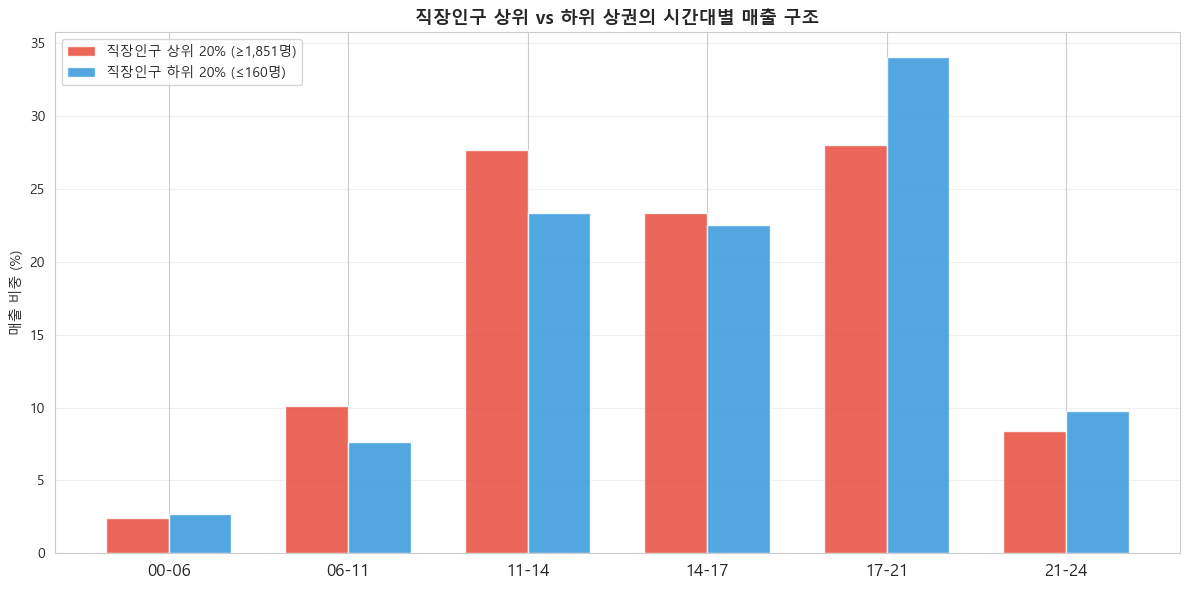

In [16]:
# %% 시간대별 매출 비중 비교 (상위20% vs 하위20%)
q80 = merged_work['총_직장_인구_수'].quantile(0.8)
q20 = merged_work['총_직장_인구_수'].quantile(0.2)
 
상위 = merged_work[merged_work['총_직장_인구_수'] >= q80]
하위 = merged_work[merged_work['총_직장_인구_수'] <= q20]
 
상위비중 = [(상위[col] / 상위['당월_매출_금액'] * 100).mean() for col in 시간_매출]
하위비중 = [(하위[col] / 하위['당월_매출_금액'] * 100).mean() for col in 시간_매출]
 
fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(6)
w = 0.35
 
ax.bar(x - w/2, 상위비중, w, color='#E74C3C', alpha=0.85, label=f'직장인구 상위 20% (≥{q80:,.0f}명)')
ax.bar(x + w/2, 하위비중, w, color='#3498DB', alpha=0.85, label=f'직장인구 하위 20% (≤{q20:,.0f}명)')

 
ax.set_xticks(x)
ax.set_xticklabels(시간라벨, fontsize=12)
ax.set_ylabel('매출 비중 (%)')
ax.set_title('직장인구 상위 vs 하위 상권의 시간대별 매출 구조', fontweight='bold', fontsize=13)
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [17]:
# %% 업종별 직장인구 효과 분석
점심_업종 = sales.copy()
점심_업종['점심비중'] = 점심_업종['시간대_11~14_매출_금액'] / 점심_업종['당월_매출_금액'].replace(0, np.nan) * 100
 
점심_업종 = 점심_업종.merge(
    df_직장[['기준_년분기_코드', '상권_코드', '총_직장_인구_수']],
    on=['기준_년분기_코드', '상권_코드'],
    how='inner'
)

In [18]:
# 직장인구 상위20% vs 하위20% 업종별 점심비중 차이
점심_상위 = 점심_업종[점심_업종['총_직장_인구_수'] >= q80].groupby('서비스_업종_코드_명')['점심비중'].mean()
점심_하위 = 점심_업종[점심_업종['총_직장_인구_수'] <= q20].groupby('서비스_업종_코드_명')['점심비중'].mean()
차이 = (점심_상위 - 점심_하위).dropna().sort_values(ascending=False)

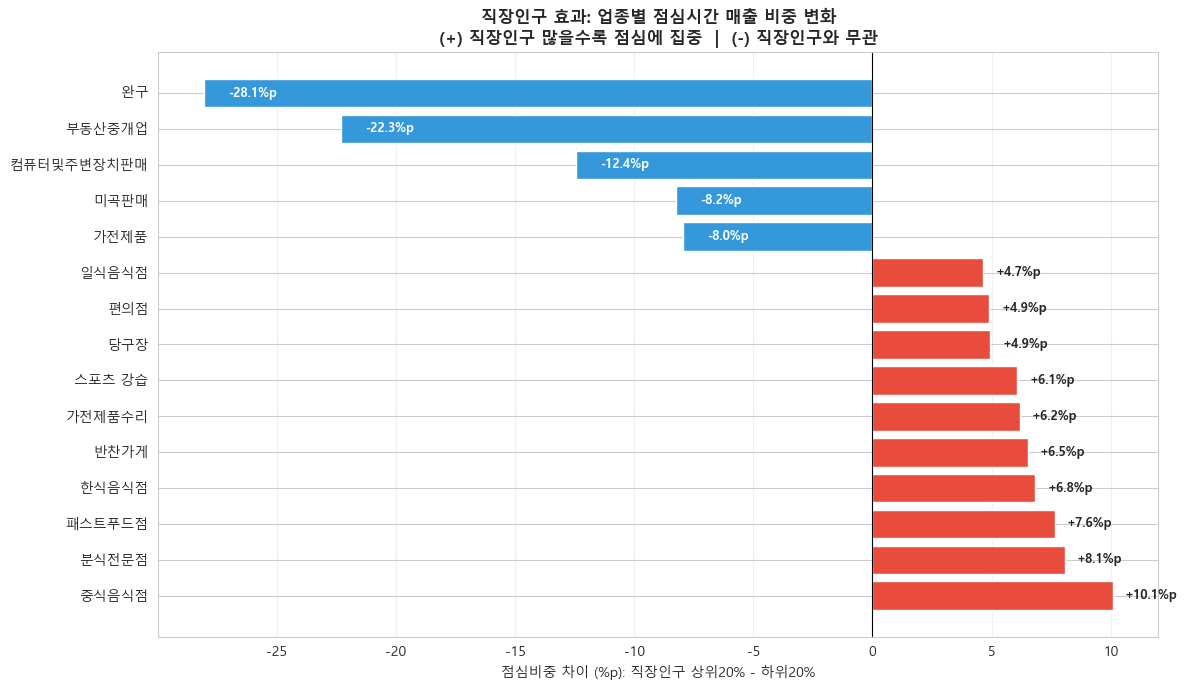

In [25]:
# 시각화: 직장인구 효과 TOP 10 + BOTTOM 5
top10 = 차이.head(10)
bot5 = 차이.tail(5)
plot_data = pd.concat([top10, bot5])
 
fig, ax = plt.subplots(figsize=(12, 7))
colors = ['#E74C3C' if v > 0 else '#3498DB' for v in plot_data.values]
bars = ax.barh(range(len(plot_data)), plot_data.values, color=colors, edgecolor='white')
ax.set_yticks(range(len(plot_data)))
ax.set_yticklabels(plot_data.index)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('점심비중 차이 (%p): 직장인구 상위20% - 하위20%')
ax.set_title('직장인구 효과: 업종별 점심시간 매출 비중 변화\n(+) 직장인구 많을수록 점심에 집중  |  (-) 직장인구와 무관', fontweight='bold')
ax.grid(axis='x', alpha=0.3)
 
# 수치 표시 - 간격 넓히기
for i, (bar, val) in enumerate(zip(bars, plot_data.values)):
    if val < 0:
        # 음수: 막대 안쪽 (오른쪽 끝)
        ax.text(val + 1.0, i, f'{val:+.1f}%p',
                va='center', ha='left', fontsize=9, fontweight='bold', color='white')
    else:
        # 양수: 막대 바깥
        ax.text(val + 0.5, i, f'{val:+.1f}%p',
                va='center', ha='left', fontsize=9, fontweight='bold')
 
plt.tight_layout()
plt.show()

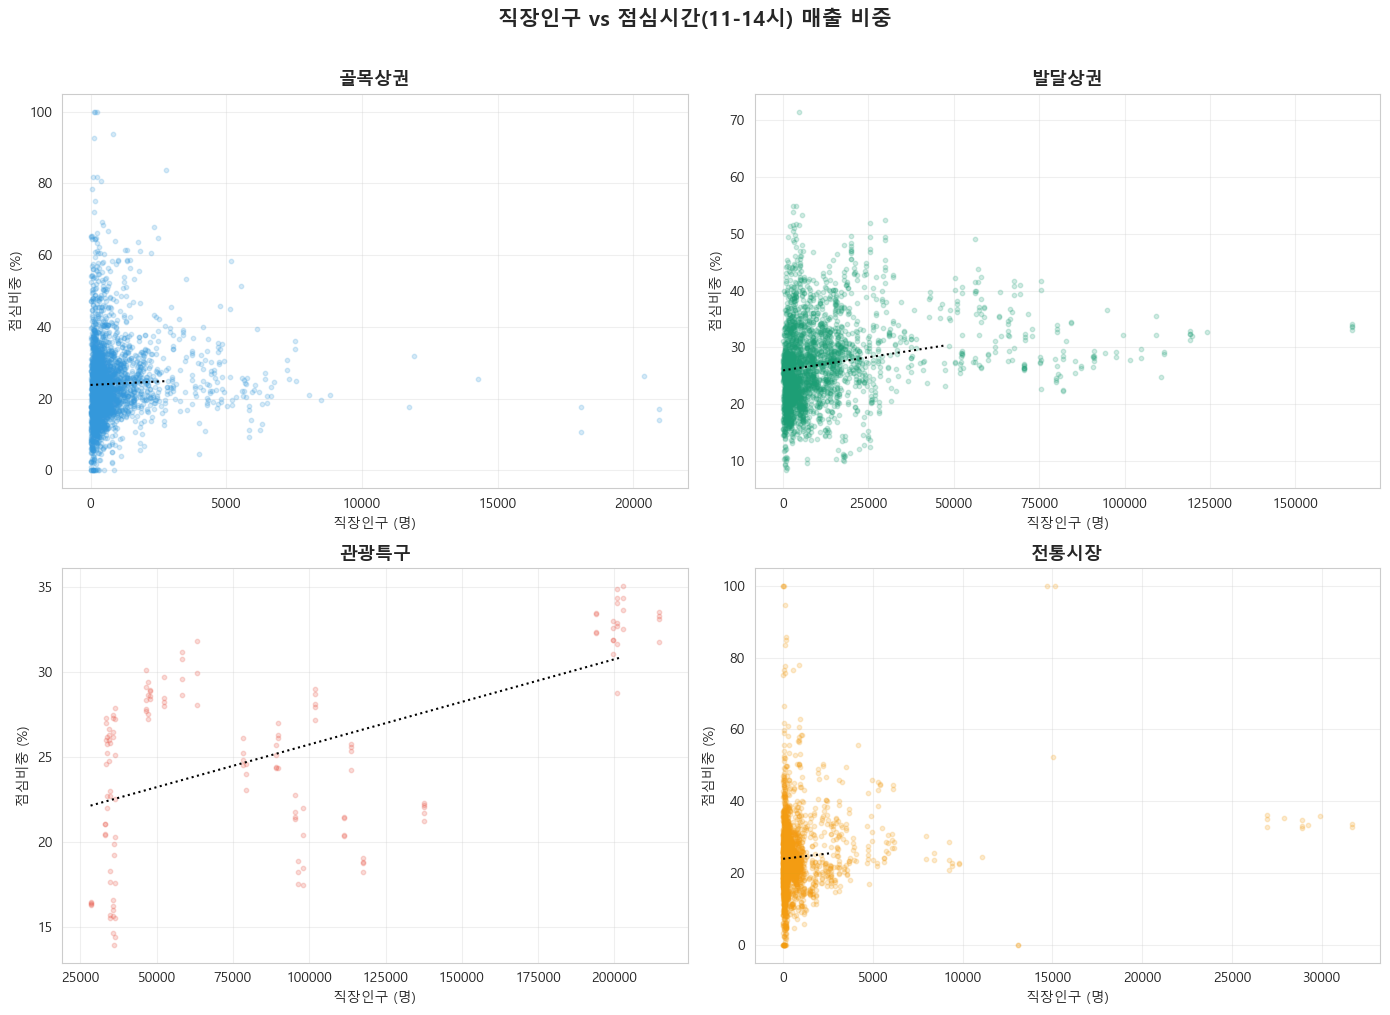

In [24]:
# %% 산점도
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()
색상 = {'골목상권':'#3498DB','발달상권':'#1D9E75','관광특구':'#E74C3C','전통시장':'#F39C12'}
 
for idx, 구분 in enumerate(상권):
    ax = axes[idx]
    sub = merged_work[merged_work['상권_구분_코드_명'] == 구분].sample(
        n=min(3000, len(merged_work[merged_work['상권_구분_코드_명'] == 구분])),
        random_state=42
    )
    ax.scatter(sub['총_직장_인구_수'], sub['점심비중'],
               alpha=0.2, s=10, color=색상[구분])
 
    # 추세선
    z = np.polyfit(sub['총_직장_인구_수'], sub['점심비중'], 1)
    p = np.poly1d(z)
    x_line = np.linspace(sub['총_직장_인구_수'].min(), sub['총_직장_인구_수'].quantile(0.95), 100)
    ax.plot(x_line, p(x_line), color='black', linewidth=1.5, linestyle=':')
 
    corr = sub[['총_직장_인구_수', '점심비중']].corr().iloc[0, 1]
    ax.set_title(f'{구분}', fontsize=13, fontweight='bold')
    ax.set_xlabel('직장인구 (명)')
    ax.set_ylabel('점심비중 (%)')
    ax.grid(alpha=0.3)
 
fig.suptitle('직장인구 vs 점심시간(11-14시) 매출 비중', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()